In [2]:
import numpy as np
import scipy.signal as signal
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from scipy.integrate import simpson

def von_karman_power(k,r0,L0,D):
    k0 = 2 * np.pi * k / L0
    var = 0.0573 * r0**(-5/3) * k0**(-5/3) * (1-(1+(k*L0/D)**2)**(-5/6))
    return var * (500e-9/(2*np.pi))**2


def generate_turbulent_psd(f, r0, L0, V, D, n):
    """
    Generates a simplified multi-layer Zernike or Phase temporal PSD.
    Uses asymptotic approximations from Conan 95 for demonstration.
    """
    fc = 0.3 * V / D * (n+1)
    if n == 1:
        psd = np.where(f < fc, (f / fc)**(-2/3), (f / fc)**(-17/3))
    else:
        psd = np.ones(len(f))
        psd[f>fc] = (f[f>fc] / fc)**(-17/3)

    vkp = von_karman_power(n, r0, L0, D)
    psd *= vkp/simpson(psd, f) # Normalize to correct area under the curve
    return psd

def evaluate_filter(params, order, delay_steps, f, fs, psd_turb, noise_floor, min_gain_margin_db=3.0):
    """
    Evaluates the residual variance for a given set of filter coefficients.
    params: [b0, b1... b_order, a1, a2... a_order]
    """
    b = params[:order+1]
    a = np.insert(params[order+1:], 0, 1.0) # a0 is fixed to 1.0
    
    # 1. Check stability (poles must be inside the unit circle)
    roots = np.roots(a)
    if np.any(np.abs(roots) >= 0.99):
        return 1e9 # Heavy penalty for instability
    
    # 2. Compute Open Loop Transfer Function (Plant is a pure delay: z^-delay)
    # H_ol(z) = C(z) * z^-d
    b_ol = np.pad(b, (delay_steps, 0), 'constant')
    w, h_ol = signal.freqz(b_ol, a, worN=f, fs=fs)
    
    # 3. Check Gain Margin
    # Find phase crossover frequency (where phase drops below -180 deg / -pi rad)
    phase = np.unwrap(np.angle(h_ol))
    crossings = np.where(phase <= -np.pi)[0]
    if len(crossings) > 0:
        idx = crossings[0]
        gain_margin_db = -20 * np.log10(np.abs(h_ol[idx]))
        if gain_margin_db < min_gain_margin_db:
            return 1e9 + (min_gain_margin_db - gain_margin_db)*1e6 # Penalty
    else:
        # If it never crosses -pi, we assume it's safe 
        gain_margin_db = np.inf
        
    # 4. Compute Sensitivity (S) and Complementary Sensitivity (T)
    # S = 1 / (1 + H_ol) -> Rejects turbulence
    # T = H_ol / (1 + H_ol) -> Amplifies noise
    S_mag2 = 1.0 / np.abs(1 + h_ol)**2
    T_mag2 = np.abs(h_ol / (1 + h_ol))**2
    
    # 5. Calculate Residual Variance Integrals
    res_turb = simpson(S_mag2 * psd_turb, f)
    res_noise = simpson(T_mag2 * noise_floor, f)
    
    total_residual = res_turb + res_noise
    return total_residual

def optimize_iir_filter(order, delay_steps, fs, r0, L0, V, D, n, noise_floor, show:bool=False):
    # Frequency vector (avoiding f=0 to prevent divide by zero)
    f = np.linspace(0.1, fs/2, 2000)
    
    # Generate Environment
    psd_turb = generate_turbulent_psd(f, r0, L0, V, D, n)
    
    # Initial Guess (Simple Integrator / Low Pass behavior)
    # b coefficients = [0.1, 0, ...], a coefficients = [-0.9, 0, ...]
    initial_guess = np.zeros(2 * order + 1)
    initial_guess[0] = 0.5 # b0
    initial_guess[order+1] = -0.9 # a1 (integration-like)

    psdInNm2 = psd_turb * 1e+18
    noiseInNm2 = (noise_floor*1e+9)**2
    
    # Minimize Residual
    print(f"Optimizing {order}-order IIR filter with {delay_steps} step delay...")
    result = minimize(
        evaluate_filter, 
        initial_guess, 
        args=(order, delay_steps, f, fs, psdInNm2, noiseInNm2),
        method='Nelder-Mead', # Robust to non-smooth penalty landscapes
        options={'maxiter': 5000, 'xatol': 1e-4}
    )
    
    if result.success:
        print("Optimization Successful!")
        b_opt = result.x[:order+1]
        a_opt = np.insert(result.x[order+1:], 0, 1.0)
        print("Optimized b:", b_opt)
        print("Optimized a:", a_opt)
        print("Minimum Residual Variance:", result.fun)
        b_ol = np.pad(b_opt, (delay_steps, 0), 'constant')
        _, h_ol = signal.freqz(b_ol, a_opt, worN=f, fs=fs)
        S_mag2 = 1.0 / np.abs(1 + h_ol)**2
        # T_mag2 = np.abs(h_ol / (1 + h_ol))**2

        if show:
            plt.figure()
            plt.loglog(f, psd_turb, label='Turbulence PSD')
            plt.loglog(f, S_mag2, label = 'Sensitivity (S)')
            plt.loglog(f, psd_turb * S_mag2, label='Residual Turbulence')
            plt.xlabel('Frequency (Hz)')
            plt.ylabel('Magnitude')
            plt.grid(which='both', ls='--')
            plt.legend()
            plt.title(f'Optimized {order}-order IIR Filter Performance')
        return b_opt, a_opt
    else:
        print("Optimization Failed.")
        return None, None

In [3]:
# n = np.arange(1,20)
# vkp = von_karman_power(n, r0=0.10, L0=25, D=8)

# plt.figure()
# plt.loglog(n[1:],vkp[1:]-vkp[:-1])
# plt.grid(which='both', ls='--')

Optimizing 2-order IIR filter with 2 step delay...
Optimization Successful!
Optimized b: [ 0.05012136 -0.00339943  0.01997043]
Optimized a: [ 1.         -0.99470455  0.0046575 ]
Minimum Residual Variance: 2683.903575921013


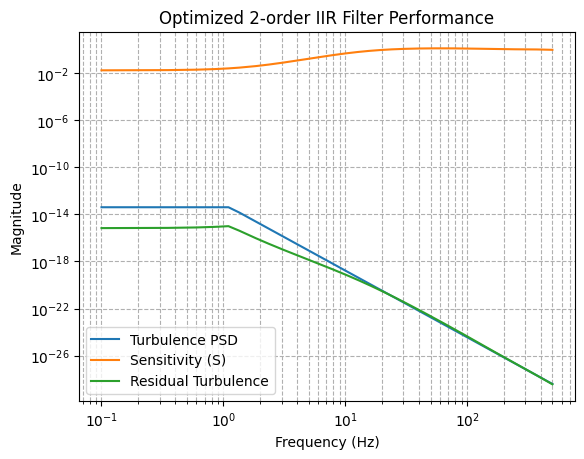

In [6]:

fs = 1000.0 # Sampling frequency (Hz)
delay_steps = 2 # 2 frames of pure delay 
order = 2 # 2nd Order IIR (2 poles, 2 zeros)

# Turbulence parameters
r0 = 0.1 # Fried parameter (m)
L0 = 25.0 # Outer scale (m)
V = 10.0 # Mean wind speed (m/s)
D = 8.0 # Telescope Diameter (m)
n = 2 # Zernike radial degree
noise_floor = 1e-8 # Flat WFS noise floor

b_opt, a_opt = optimize_iir_filter(order, delay_steps, fs, r0, L0, V, D, n, noise_floor, show=True)